# Customer Churn Prediction in E-commerce

This notebook aims to preprocess and clean the data from an e-commerce platform to predict customer churn. The dataset contains several customer-related features such as purchase history, user behavior, and demographic details.

### Objective:
- Perform data cleaning and preprocessing on the customer churn dataset.
- Explore data using visualizations.
- Identify relationships and patterns that might be useful for churn prediction.

---

In [24]:
import pandas as pd   
import numpy as np        
import matplotlib.pyplot as plt   
import seaborn as sns 
import missingno as msno

In [13]:
df = pd.read_csv("../data/raw/ECommerceDataset.csv")

df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [14]:
df.shape

(5630, 20)

There are in total of 5630 rows and 20 columns. Among 20 columns we have 5 categorical column.

In [15]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


### Churn Rate Analysis

The **Churn** column represents whether a customer has churned (1) or remained active (0). The mean of the churn column is **0.168**, meaning that **16.8%** of customers have churned, while the remaining **83.2%** are still active.

It gives us understanding that most of the customers are active, and we need to carefully handle this imbalance when later building predictive models, as this imbalanced datasets might lead to biased predictions.


# Customer Churn Prediction - Data Cleaning and Preprocessing

## Missing Data Analysis
- Some features have missing values, with a maximum of 5.45% missing in total.
- The missing values are primarily found in numerical features (float64 columns).
- We performed the following steps for handling missing values:
  - Imputation for Numerical Features: Missing values in the numerical columns were imputed using the median value of the respective column. This approach is robust to outliers and preserves the distribution of data.
  - No columns were dropped, as the percentage of missing data was minimal.
- Outcome: After imputation, all missing values were handled, and no missing values remain in the dataset.
- Advanced methods like KNN imputation or regression-based imputation could be considered in the future if more complex patterns of missing data arise.

---


In [17]:
missing_values = df.isnull().sum()
missing_values

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [23]:
len(df)

5630

In [19]:
missing_percentage = (missing_values / len(df)) * 100
missing_percentage

CustomerID                     0.000000
Churn                          0.000000
Tenure                         4.689165
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.458259
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.529307
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
CashbackAmount                 0.000000
dtype: float64

In [22]:
missing_df = pd.DataFrame({'Missing Values' : missing_values, 'Percentage' : missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending = False)
missing_df

,Missing Values,Percentage
DaySinceLastOrder,307,5.452931
OrderAmountHikeFromlastYear,265,4.706927
Tenure,264,4.689165
OrderCount,258,4.582593
CouponUsed,256,4.547069
HourSpendOnApp,255,4.529307
WarehouseToHome,251,4.458259


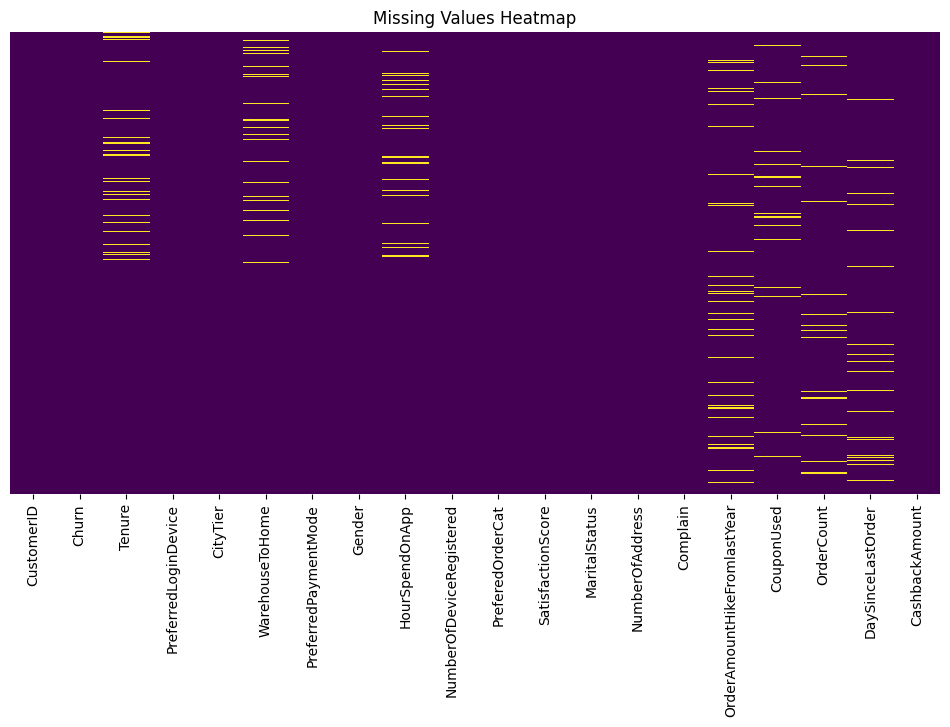

In [33]:
plt.figure(figsize = (12, 6))
sns.heatmap(df.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

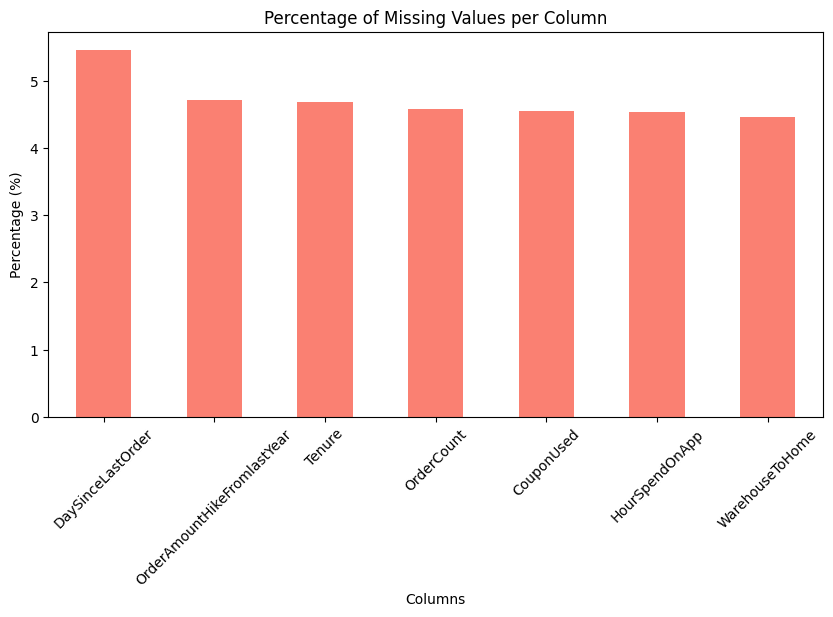

In [31]:
plt.figure(figsize=(10,5))
missing_df['Percentage'].plot(kind='bar', color='salmon')
plt.title("Percentage of Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Percentage (%)")
plt.xticks(rotation = 45)
plt.show()

In [43]:
df.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
missing_count                    int64
dtype: object

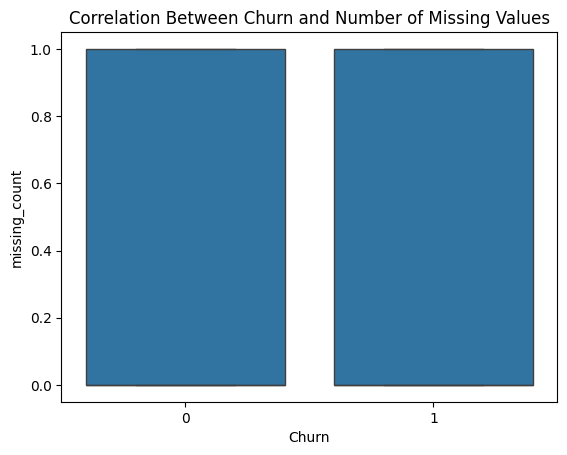

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,missing_count
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,...,2,Single,9,1,11.0,1.0,1.0,5.0,160,0
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,...,3,Single,7,1,15.0,0.0,1.0,0.0,121,1
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,...,3,Single,6,1,14.0,0.0,1.0,3.0,120,1
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,5,Single,8,0,23.0,0.0,1.0,3.0,134,0
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,...,5,Single,3,0,11.0,1.0,1.0,3.0,130,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,...,1,Married,6,0,18.0,1.0,2.0,4.0,151,0
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,...,5,Married,6,0,16.0,1.0,2.0,NaN,225,1
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,...,4,Married,3,1,21.0,1.0,2.0,4.0,186,0
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,...,4,Married,4,0,15.0,2.0,2.0,9.0,179,0


In [37]:
df_missing_churn = df.copy()
df_missing_churn['missing_count'] = df_missing_churn.isnull().sum(axis = 1)

sns.boxplot(x = 'Churn', y = 'missing_count', data=df_missing_churn)
plt.title("Correlation Between Churn and Number of Missing Values")
plt.show()

df_missing_churn

In [38]:
missing_by_churn = df.groupby('Churn')['missing_count'].describe()
print(missing_by_churn)

        count      mean       std  min  25%  50%  75%  max
Churn                                                     
0      4682.0  0.328706  0.469793  0.0  0.0  0.0  1.0  1.0
1       948.0  0.334388  0.472025  0.0  0.0  0.0  1.0  1.0


In [44]:
missing_columns = df.columns[df.isnull().any()]
df[missing_columns].isnull().sum()

Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

In [48]:
numerical_cols = df[missing_columns].select_dtypes(include=['float64']).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum().sum()

np.int64(0)

In [49]:
missing_values_recheck = df.isnull().sum()
missing_values_recheck

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
missing_count                  0
dtype: int64